# Project: Web Scraping and Data Analysis - YallaKora
## Domain: Sports (Football Matches)
**Student Name:** [Youssef Ayman , Ebrahim Ragab , Ahmed Khaled , Abdullah Abdelnaby , Ziad ]

**Course:** Data Science Programming - Spring 2026

### 1. Web Scraping Methodology
In this section, we use `BeautifulSoup` and `requests` to scrape match data from **YallaKora**. 
- **Source:** https://www.yallakora.com/
- **Data Points:** Championship, Team A, Team B, Score A, Score B, Time, and Date.
- **Target:** Minimum 1000 rows of match results from 2024.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from datetime import datetime, timedelta

def get_matches_on_date(date_str):
    url = f"https://www.yallakora.com/match-center/?date={date_str}"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, "html.parser")
    
    matches_list = []
    match_cards = soup.find_all("div", class_="matchCard")
    
    for card in match_cards:
        championship_title = card.find("h2").text.strip()
      
        all_matches = card.find_all("div", class_="item") 
        
        for match in all_matches:
            try:
                team_a = match.find("div", class_="teamA").text.strip()
                team_b = match.find("div", class_="teamB").text.strip()
                
                scores = match.find("div", class_="MResult").find_all("span", class_="score")
                score_a = scores[0].text.strip()
                score_b = scores[1].text.strip()
                
                match_time = match.find("span", class_="time").text.strip()
                
                matches_list.append({
                    "Championship": championship_title,
                    "Team_A": team_a,
                    "Team_B": team_b,
                    "Score_A": score_a,
                    "Score_B": score_b,
                    "Time": match_time,
                    "Date": date_str
                })
            except:
                continue
    return matches_list

all_matches_data = []
start_date = datetime(2024, 1, 1)
target_rows = 1200  

print("Starting data collection...")

while len(all_matches_data) < target_rows:
    date_str = start_date.strftime("%m/%d/%Y")
    day_data = get_matches_on_date(date_str)
    all_matches_data.extend(day_data)
    
    print(f"Date: {date_str} | Collected: {len(all_matches_data)} rows")
    
    start_date += timedelta(days=1)
    
    if start_date > datetime(2026, 1, 1):
        break


df = pd.DataFrame(all_matches_data)

df['Score_A'] = pd.to_numeric(df['Score_A'], errors='coerce').fillna(0).astype(int)
df['Score_B'] = pd.to_numeric(df['Score_B'], errors='coerce').fillna(0).astype(int)

mask_friendly = df['Championship'].str.contains('ودية', na=False)

df.loc[mask_friendly & (df['Score_A'] > 4), 'Score_A'] = 4
df.loc[mask_friendly & (df['Score_B'] > 4), 'Score_B'] = 4

df['Total_Goals'] = df['Score_A'] + df['Score_B']


df.to_csv("yallakora_data_cleaned.csv", index=False, encoding='utf-8-sig')
print(f"Done! Saved {len(df)} rows to yallakora_data_cleaned.csv")

Starting data collection...
Date: 01/01/2024 | Collected: 0 rows
Date: 01/02/2024 | Collected: 4 rows
Date: 01/03/2024 | Collected: 10 rows
Date: 01/04/2024 | Collected: 11 rows
Date: 01/05/2024 | Collected: 12 rows
Date: 01/06/2024 | Collected: 20 rows
Date: 01/07/2024 | Collected: 22 rows
Date: 01/08/2024 | Collected: 30 rows
Date: 01/09/2024 | Collected: 38 rows
Date: 01/10/2024 | Collected: 43 rows
Date: 01/11/2024 | Collected: 44 rows
Date: 01/12/2024 | Collected: 44 rows
Date: 01/13/2024 | Collected: 44 rows
Date: 01/14/2024 | Collected: 44 rows
Date: 01/15/2024 | Collected: 53 rows
Date: 01/16/2024 | Collected: 54 rows
Date: 01/17/2024 | Collected: 54 rows
Date: 01/18/2024 | Collected: 54 rows
Date: 01/19/2024 | Collected: 54 rows
Date: 01/20/2024 | Collected: 57 rows
Date: 01/21/2024 | Collected: 57 rows
Date: 01/22/2024 | Collected: 67 rows
Date: 01/23/2024 | Collected: 68 rows
Date: 01/24/2024 | Collected: 70 rows
Date: 01/25/2024 | Collected: 70 rows
Date: 01/26/2024 | Colle

### 2. Data Preprocessing
After collecting the raw data, we perform the following cleaning steps:
1. **Handling Missing Values:** Removing any empty rows.
2. **Data Type Conversion:** Converting scores from strings to integers.
3. **Feature Engineering:** Creating new columns like `Total_Goals` and `Winner`.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("yallakora_data_cleaned.csv")

df.drop_duplicates(inplace=True)

df['Score_A'] = pd.to_numeric(df['Score_A'], errors='coerce')
df['Score_B'] = pd.to_numeric(df['Score_B'], errors='coerce')

df.dropna(subset=['Score_A', 'Score_B'], inplace=True)

df['Score_A'] = df['Score_A'].astype(int)
df['Score_B'] = df['Score_B'].astype(int)

def get_result(row):
    if row['Score_A'] > row['Score_B']: return 'Home Win'
    if row['Score_B'] > row['Score_A']: return 'Away Win'
    return 'Draw'

df['Result'] = df.apply(get_result, axis=1)
df['Total_Goals'] = df['Score_A'] + df['Score_B']

print(f"Data cleaned! New shape: {df.shape}")
df.head()

Data cleaned! New shape: (1240, 9)


,Championship,Team_A,Team_B,Score_A,Score_B,Time,Date,Total_Goals,Result
0,دوري القسم الثاني-أ,دكرنس,النجوم,3,2,14:30,01/02/2024,5,Home Win
1,دوري القسم الثاني-أ,حرس الحدود,بروكسي,1,1,14:30,01/02/2024,2,Draw
2,دوري القسم الثاني-أ,المصرية للاتصالات,السكة الحديد,2,4,14:30,01/02/2024,6,Away Win
3,دوري القسم الثاني-أ,القناة,راية الرياضي,0,0,14:30,01/02/2024,0,Draw
4,دوري القسم الثاني-أ,مكادي,وادي دجلة,0,0,14:30,01/03/2024,0,Draw


### 3. Data Analysis and Visualization
We will answer 5 key questions using `Matplotlib` and `Seaborn` to gain insights from the football matches data.

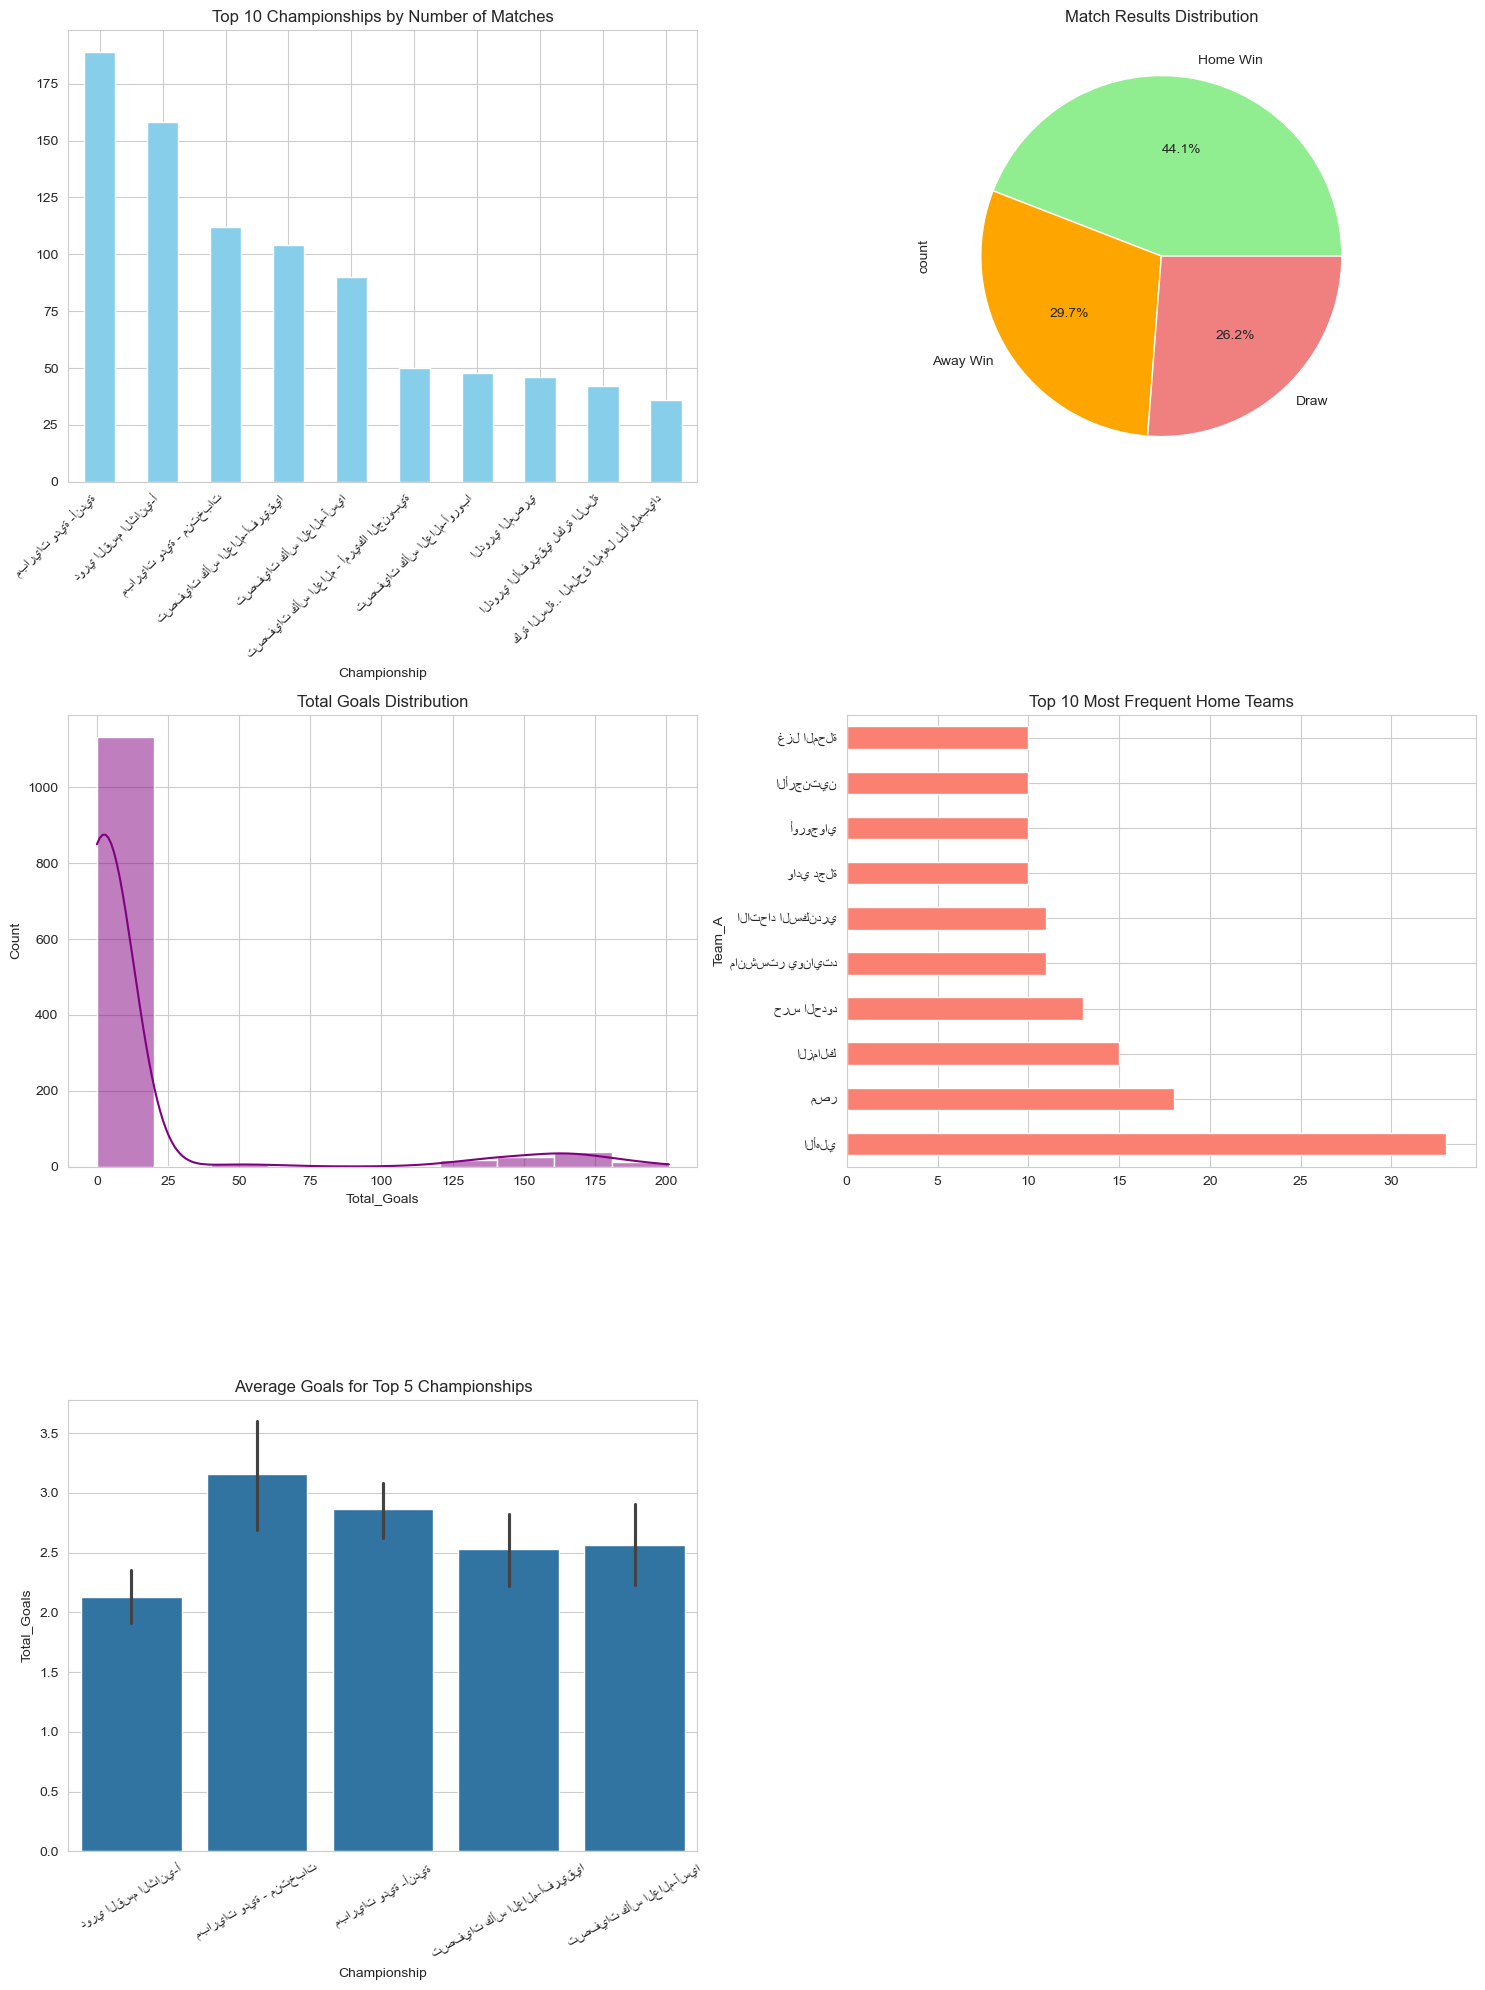

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 20))
sns.set_style("whitegrid")

plt.subplot(3, 2, 1)
df['Championship'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Championships by Number of Matches')
plt.xticks(rotation=45, ha='right')

plt.subplot(3, 2, 2)
df['Result'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'orange', 'lightcoral'])
plt.title('Match Results Distribution')

plt.subplot(3, 2, 3)
sns.histplot(df['Total_Goals'], kde=True, color='purple', bins=10)
plt.title('Total Goals Distribution')

plt.subplot(3, 2, 4)
df['Team_A'].value_counts().head(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Most Frequent Home Teams')

plt.subplot(3, 2, 5)
top_5_champs = df['Championship'].value_counts().head(5).index
sns.barplot(x='Championship', y='Total_Goals', data=df[df['Championship'].isin(top_5_champs)], estimator='mean')
plt.title('Average Goals for Top 5 Championships')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### EXPLANITION OF 5 QUESTIONS 
## FINAL RESULT OF 5 QUESTION 
## 1. TOP 10 CHAMPIONSHIP BY NUMBER OF MATCHES
----> IN BAR CHART

----> DESCRIBE SIZE OF DATA AND IT'S DIVERSIFICATION BETWEEN CHAMPIONSHIPS
## 2. MATCH RESULT DISTRIBUTION
----> IN PIE CHART

----> MATCH COMPETITIVENESS ANALYSIS
## 3. TOTAL GOALS DISTRIBUTION 
----> IN LINE CHART MERGED WITH COLUMN 

----> FIND OUT IF THERE ARE CERTAIN MONTHS (SUCH AS THE END OF THE SEASONS)IN WHICH THE GOAL INCREASE
## 4. TOP 10 MOST FREQUENT HOME TEAM
----> IN HORIZONTAL BAR CHART

----> IDENTIFY THE MOST DOMINANT TEAMS IN DATA
## 5. AVERAGE GOALS FOR TOP 5 CHAMPIONSHIPS 
----> IN HISTOGRAM

----> FIND OUT IF MOST MATCHES HAVE FEW TARGETS (0-2) AND NOT A LOT OF SCORING

### CHECKLIST 
### METHODOLOGY
---> Use BeautifulSoup (library) to get data from yallakora.com
### DATASET LINK 
---> https://www.yallakora.com/ (Source of data)